**What are we trying to prove?**

We want to visually and numerically prove that:

- Underfitting happens when the model is too simple

- Overfitting happens when the model is too complex

- There exists a point where the model generalizes well

**Import libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

**Generate input feature X**

- We create 100 evenly spaced values between -3 and 3


In [ ]:
np.random.seed(0)

# Generate input feature
X = np.linspace(-3, 3, 100).reshape(-1, 1)

**Define the TRUE function (unknown to model)**

In [ ]:
# True underlying function (unknown to model)
y_true = 0.5 * X**3 - X**2 + X + 3

**Add noise**

- Noise simulates measurement errors

- Prevents perfect fitting

- Creates the risk of overfitting

In [ ]:
y = y_true + np.random.normal(0, 3, size=y_true.shape)

**Train–test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Helper function (training + evaluation + plotting)**

In [ ]:
def train_and_plot(degree, title):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("lin_reg", LinearRegression())
    ])

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Plot
    X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.figure(figsize=(7,5))
    plt.scatter(X_train, y_train, color="blue", label="Train data")
    plt.scatter(X_test, y_test, color="green", label="Test data")
    plt.plot(X_plot, y_plot, color="red", linewidth=2)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Polynomial Degree: {degree}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Test  MSE: {test_mse:.2f}")
    print("-" * 40)

**UNDERFITTING (Degree = 1)**

Why does this model underfit?

- True data is cubic

- Model is linear

- Cannot bend

Result:

-High training error

- High test error

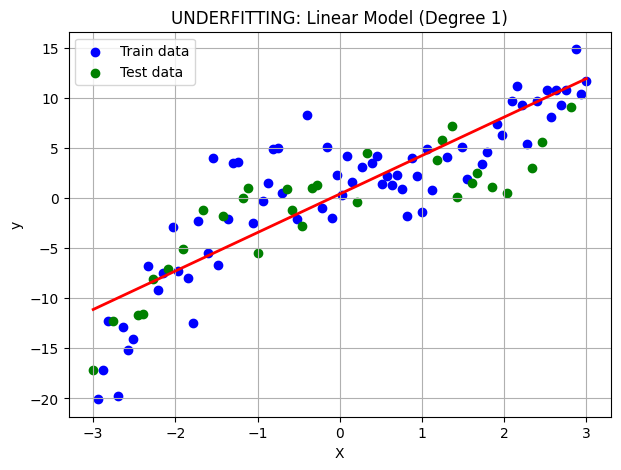

Polynomial Degree: 1
Train MSE: 15.40
Test  MSE: 13.85
----------------------------------------


In [ ]:
train_and_plot(
    degree=1,
    title="UNDERFITTING: Linear Model (Degree 1)"
)


**GOOD FIT (Degree = 4)**

Why does this model work?

- Degree ≥ true function degree

- Enough flexibility

- Not too many parameters

Result

- Low training error

- Low test error

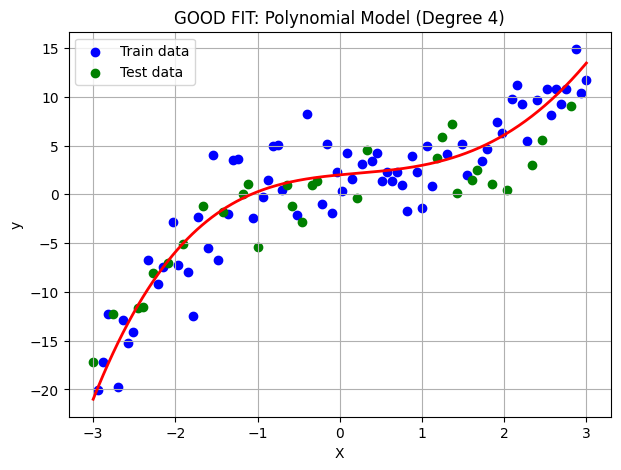

Polynomial Degree: 4
Train MSE: 7.90
Test  MSE: 8.23
----------------------------------------


In [ ]:
train_and_plot(
    degree=4,
    title="GOOD FIT: Polynomial Model (Degree 4)"
)

**OVERFITTING (Degree = 15)**

Why does this model overfit?

- Too many parameters

- Tries to pass through every training point

- Learns noise patterns

Result

- Very low training error

- High test error

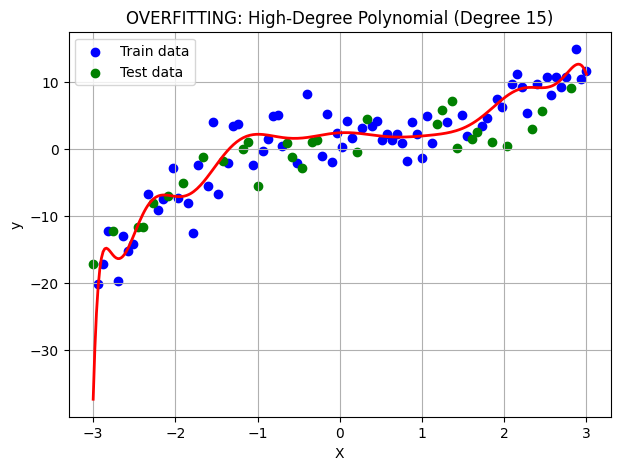

Polynomial Degree: 15
Train MSE: 6.42
Test  MSE: 24.44
----------------------------------------


In [ ]:
train_and_plot(
    degree=15,
    title="OVERFITTING: High-Degree Polynomial (Degree 15)"
)

**Fix underfitting**

- Increase model complexity

- Add features

- Train longer

**Fix overfitting**

- Reduce model complexity

- Add more data

- Use regularization (Ridge/Lasso)

- Cross-validation